#Medical Appointment No-Show Prediction
Team:

alauper@csumb.edu (Arielle Lauper)

imiyasato@csumb.edu (Ichiro Miyasato)

kelismith@csumb.edu (Kelia Smith)

mimperatrice@csumb.edu (Maria Imperatrice)

## Introduction

This project aims to predict which patients are likely to miss medical appointments based on factors such as age, medical conditions, and receipt of reminder text messages. Using a dataset on patient no-shows, we will develop a supervised learning model trained on labeled data to identify patients at risk of missing appointments. Unsupervised learning will further refine the model by uncovering patterns in the data.

Missed appointments waste healthcare providers' time, delay care for other patients, and reduce office revenue. Predicting no-shows can help medical staff better prepare for and mitigate their impact.

The project involves analyzing factors contributing to no-shows to create a predictive model. The goal is to help healthcare providers reduce no-show rates, improve scheduling efficiency, and optimize resource allocation. Deliverables include data analysis, modeling, interpretation, and recommendations.

## Descriptions

### Dataset
Data URL: [Kaggle.com: Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments)

Data Licence: [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/)

Date Downloaded: June 3rd, 2025

The dataset, obtained from Kaggle, includes over 100,000 records of medical appointments in Brazilian clinics. It captures patient details such as age, gender, neighborhood, appointment date, health conditions like hypertension, alcoholism, and diabetes, and a binary indicator of patient attendance. It is ideal for classification analysis due to its explicit no-show label. Data preparation will involve standardizing date formats, encoding categorical fields like clinic location, and resolving missing entries. One metric that could be derived could be the number of days between the appointment scheduling date and the actual appointment date. Another could be the number of repeat no-shows by a distinct patient.  

The dataset’s unique blend of clinical and demographic information, set in a Brazilian context, distinguishes it from standard healthcare datasets, offering a novel perspective for analysis that diverges from United States medical studies.


### Prediction Goal

Build a binary classification system to predict whether a patient will miss their scheduled medical appointment (No-show = Yes) based on a feature set including age, medical conditions (hypertension, diabetes, alcoholism, handicap), SMS receipt, appointment day of the week, and history of prior no-shows.

### Features to be used as predictors:
* Demographics
  * Age
  * Gender
* Medical
  * Hypertension  
  * Diabetes
  * Alcoholism
  * Handicap
* Schedule Related
  * SMS Received
  * Day of the Week
* Behavioral
  * Past-Missed





## Data Preparation

Import libraries

In [375]:
# refs: https://www.geeksforgeeks.org/python-numpy-isin-method/#
#       https://stackoverflow.com/questions/28009370/get-weekday-day-of-week-for-datetime-column-of-dataframe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.inspection import permutation_importance
from matplotlib import rcParams

Read in data

In [376]:
df = pd.read_csv('https://raw.githubusercontent.com/A-Lauper/Medical-Appointment-No-Show-Prediction/refs/heads/main/data/KaggleV2-May-2016.csv')

Set plot style

In [377]:
rcParams['figure.figsize'] = (6, 4)

In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Standardize column names

In [379]:
df.columns = df.columns.str.lower().str.replace('-', '_')
df.rename(columns={'hipertension': 'hypertension'}, inplace=True)

Convert dates

In [380]:
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

Derived features

In [381]:
df['days_between'] = (df['appointmentday'] - df['scheduledday']).dt.days
df['day_of_week'] = df['appointmentday'].dt.day_name().map({
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
})

Encode data:

In [382]:
df['no_show'] = (df['no_show'] == 'Yes').values.astype(int)
df['is_male'] = (df['gender'] == 'M').values.astype(int)
df['past_missed'] = np.isin(df['patientid'], df[df['no_show'] == 1]['patientid']).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

Handle invalid data

In [383]:
df = df[df['days_between'] >= 0].copy()  # Create a copy to avoid view issues
df.loc[df['age'] <= 0, 'age'] = np.nan  # Replace -1 and 0 with NaN
df.loc[df['age'] > 100, 'age'] = 100  # Cap age at 100
df = df.dropna()  # Remove rows with NaN values

Standardize numerical features

In [384]:
df.loc[:, 'age'] = zscore(df['age'])
df['days_between'] = df['days_between'].astype(float)  # Cast to float to avoid dtype mismatch
df.loc[:, 'days_between'] = zscore(df['days_between'])

Drop unneeded columns:

In [385]:
df = df.drop(['neighbourhood'], axis=1)

Display processed data

In [386]:
df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,scholarship,hypertension,diabetes,alcoholism,handcap,sms_received,no_show,days_between,day_of_week,is_male,past_missed,is_weekend
5,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,1.632834,0,1,0,0,0,0,0,-0.822221,4,0,0,0
6,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,-0.749664,0,0,0,0,0,0,1,-0.822221,4,0,1,0
7,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,-0.030419,0,0,0,0,0,0,1,-0.822221,4,0,1,0
9,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,-0.929475,0,0,0,0,0,0,0,-0.822221,4,0,0,0
10,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,-0.434994,0,0,0,0,0,0,0,-0.822221,4,0,0,0


**Notes**: We standardized column names, encoded `no_show`, `is_male`, and `past_missed`, and converted dates. Derived features include `days_between` and `day_of_week`. Invalid ages (-1, 0) were replaced with NaN, and ages above 100 were capped. Numerical features were standardized. We dropped `neighbourhood` and other unneeded columns to avoid complex encoding

## Data Exploration and Visualization

We explore feature distributions and no-show relationships, noting the dataset’s imbalance (approximately 20% no-shows).

No-show Distribution

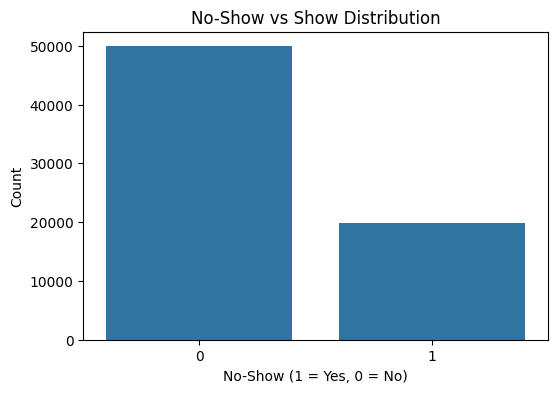

In [387]:
sns.countplot(x='no_show', data=df)
plt.title('No-Show vs Show Distribution')
plt.xlabel('No-Show (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

Feature Correlation Heatmap

Text(0.5, 1.0, 'Feature Correlation Heatmap')

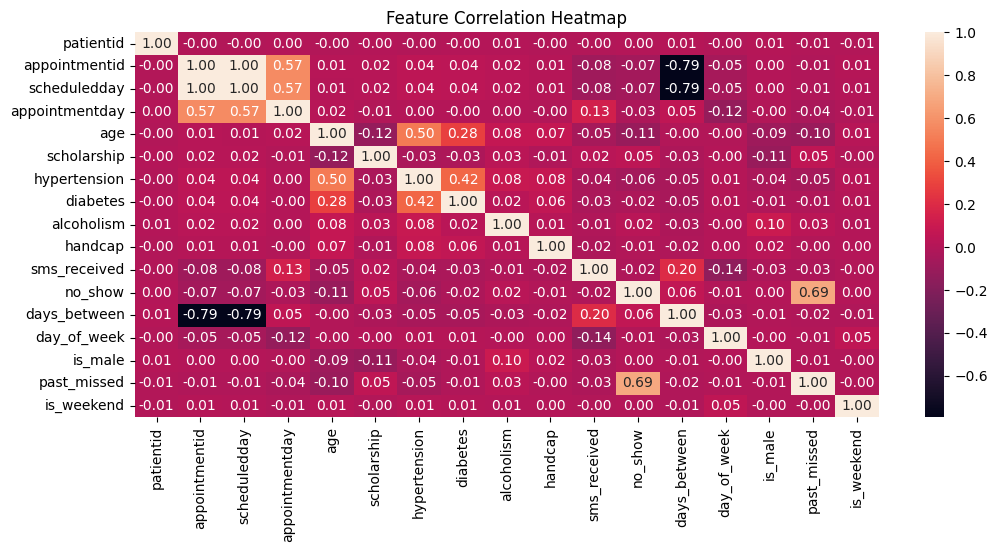

In [388]:
df2 = df.drop(['gender'], axis=1)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df2.corr(), annot=True, fmt=".2f")
plt.title('Feature Correlation Heatmap')

The most strongly correlated feature with appointment no shows appears to be past_missed. If a patient has previously missed an appointment in the past, there is a positive correlation that they will miss this appointment as well. In addition, there seems to be a small positive correlation with days_between. This indicates that patient are slightly more likely to miss their appointment if there is a large gap between when they scheduled the appointment and when the appointment date is set. There is also a small negative correlation with the features age and hypertension. This indicates that older patient, and those with high blood pressure are slightly more likely to make their appointments.

Relatively small impact from text message reminders.

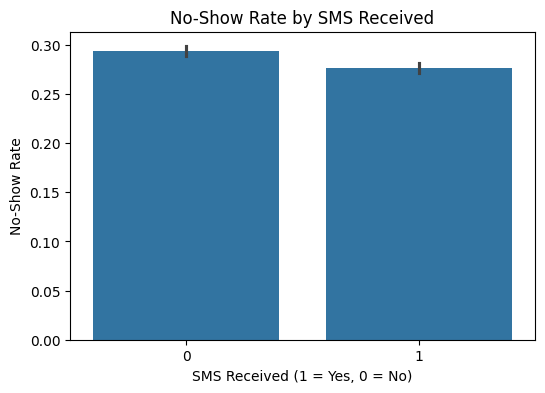

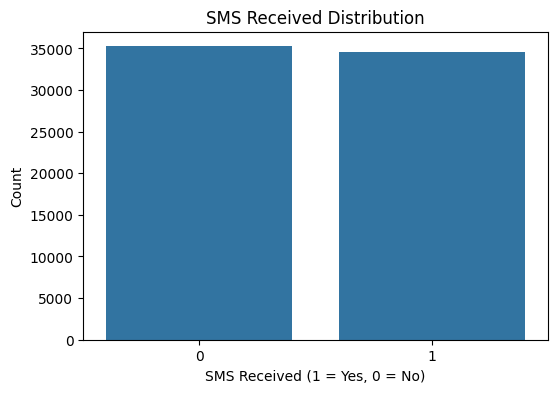

In [389]:
sns.barplot(x='sms_received', y='no_show', data=df)
plt.title('No-Show Rate by SMS Received')
plt.xlabel('SMS Received (1 = Yes, 0 = No)')
plt.ylabel('No-Show Rate')
plt.show()
sns.countplot(x=df['sms_received'])
plt.title('SMS Received Distribution')
plt.xlabel('SMS Received (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

High error rate for Saturday.

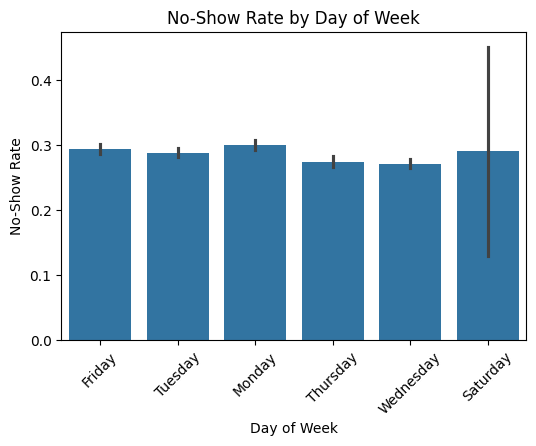

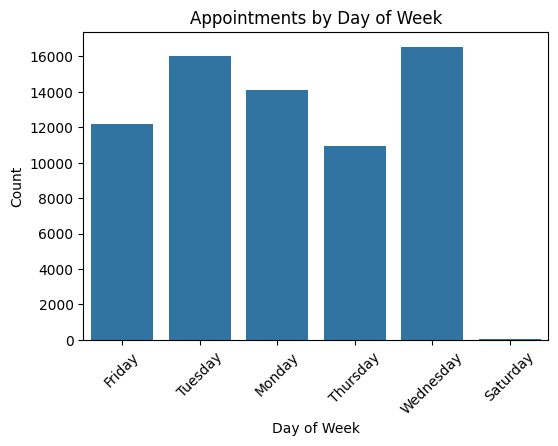

In [390]:
sns.barplot(x=df['appointmentday'].dt.day_name(), y=df['no_show'])
plt.title('No-Show Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('No-Show Rate')
plt.xticks(rotation=45)
plt.show()
sns.countplot(x=df['appointmentday'].dt.day_name())
plt.title('Appointments by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Age vs No-Show

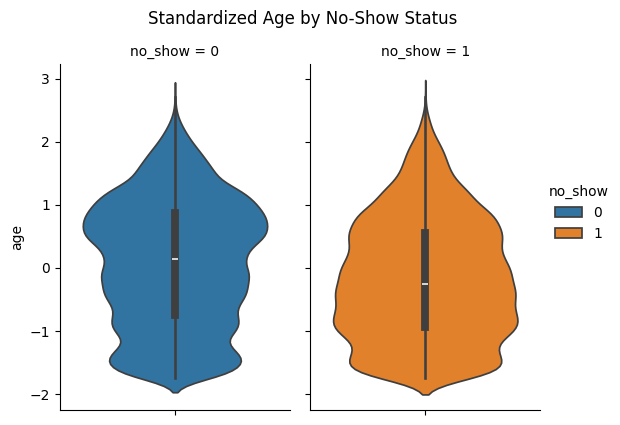

In [391]:
sns.catplot(y=df['age'], col=df['no_show'], kind='violin', hue=df['no_show'], height=4, aspect=0.7)
plt.suptitle('Standardized Age by No-Show Status', y=1.05)
plt.show()

In [392]:
print('Min age z-score:', df['age'].min())
print('Max age z-score:', df['age'].max())

Min age z-score: -1.7386251043136087
Max age z-score: 2.711700907239274


Distribution of Days Between Scheduled and Appointment

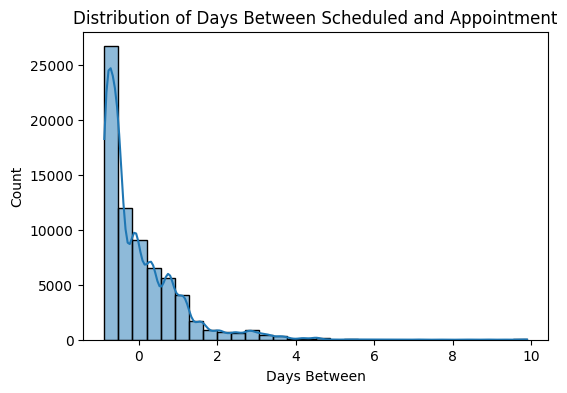

In [393]:
plt.figure(figsize=(6,4))
sns.histplot(df['days_between'], bins=30, kde=True)
plt.title('Distribution of Days Between Scheduled and Appointment')
plt.xlabel('Days Between')
plt.ylabel('Count')
plt.show()

**Findings**:  
- Approximately 20% of appointments are no-shows, indicating imbalance, requiring metrics like precision and recall.  
- Patients with SMS reminders have higher no-show rates, possibly due to targeted reminders.  
- Saturday appointments show higher no-show rates, but data is sparse.  
- Younger patients (lower z-scores) are more likely to miss appointments (violin plot).  

## Machine Learning

Select features and target

In [394]:
features = ['age', 'hypertension', 'diabetes', 'alcoholism', 'handcap',
            'sms_received', 'days_between', 'day_of_week', 'past_missed']
X = df[features].values
y = df['no_show'].values

Train-test split

In [395]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=115)

Metrics function

In [396]:
def compute_metrics(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    accuracy = np.mean(y_pred == y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    conf_matrix = np.array([[tn, fp], [fn, tp]])
    return accuracy, precision, recall, conf_matrix

Baseline model: Predict majority class (always predict No-show = No)

In [397]:
baseline_pred = np.zeros_like(y_test)
acc, prec, rec, cm = compute_metrics(y_test, baseline_pred)
print("Majority Baseline:")
print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}")

Majority Baseline:
Accuracy: 0.715, Precision: 0.000, Recall: 0.000


Median-based baseline

In [398]:
median_rate = np.median(y_train)
median_pred = np.zeros_like(y_test) if median_rate == 0 else np.ones_like(y_test)
acc, prec, rec, cm = compute_metrics(y_test, median_pred)
print("\nMedian Baseline:")
print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}")


Median Baseline:
Accuracy: 0.715, Precision: 0.000, Recall: 0.000


Confusion Matrix for both baselines

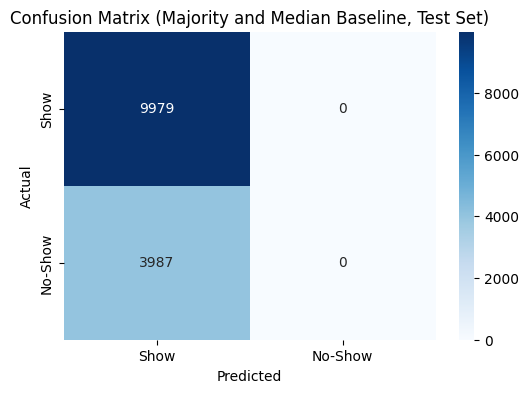

In [399]:
sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
plt.title('Confusion Matrix (Majority and Median Baseline, Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN Classification

In [400]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn, prec_knn, rec_knn, cm_knn = compute_metrics(y_test, y_pred_knn)
print("KNN Classification (k=3):")
print(f"Accuracy: {acc_knn:.3f}, Precision: {prec_knn:.3f}, Recall: {rec_knn:.3f}")

KNN Classification (k=3):
Accuracy: 0.813, Precision: 0.660, Recall: 0.711


Confusion matrix for KNN

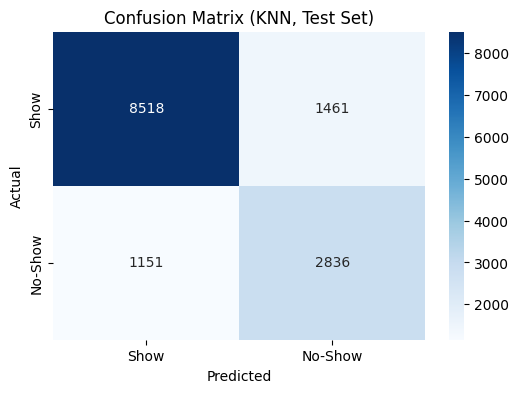

In [401]:
sns.heatmap(cm_knn, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
plt.title('Confusion Matrix (KNN, Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Random Forest classification

In [402]:
rf = RandomForestClassifier(n_estimators=100, random_state=115, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf, prec_rf, rec_rf, cm_rf = compute_metrics(y_test, y_pred_rf)
print("Random Forest Classification:")
print(f"Accuracy: {acc_rf:.3f}, Precision: {prec_rf:.3f}, Recall: {rec_rf:.3f}")

Random Forest Classification:
Accuracy: 0.817, Precision: 0.647, Recall: 0.788


Confusion matrix for Random Forest

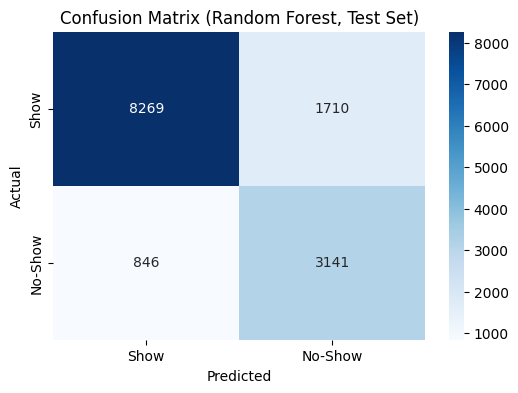

In [403]:
sns.heatmap(cm_rf, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Show', 'No-Show'], yticklabels=['Show', 'No-Show'])
plt.title('Confusion Matrix (Random Forest, Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KMeans Clustering: Grouping patients based on features and then analyzing/visualizing how these clusters relate to no-show rates.

== Cluster: Young, Low-Need ==
         medical_risk  behavioral_risk  demographics
no_show                                             
0            0.011429         0.274560      0.118104
1            0.012675         0.556236      0.106706


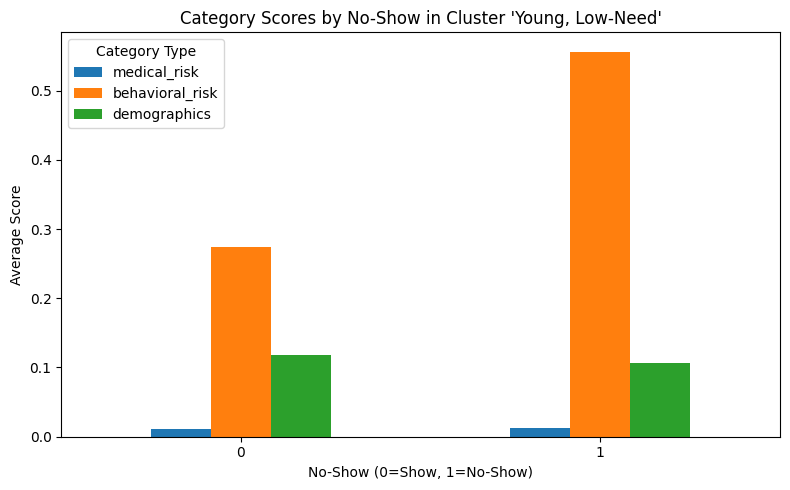

== Cluster: Mixed-Age, Moderate ==
         medical_risk  behavioral_risk  demographics
no_show                                             
0            0.090968         0.185046      1.789625
1            0.074712         0.486087      1.688807


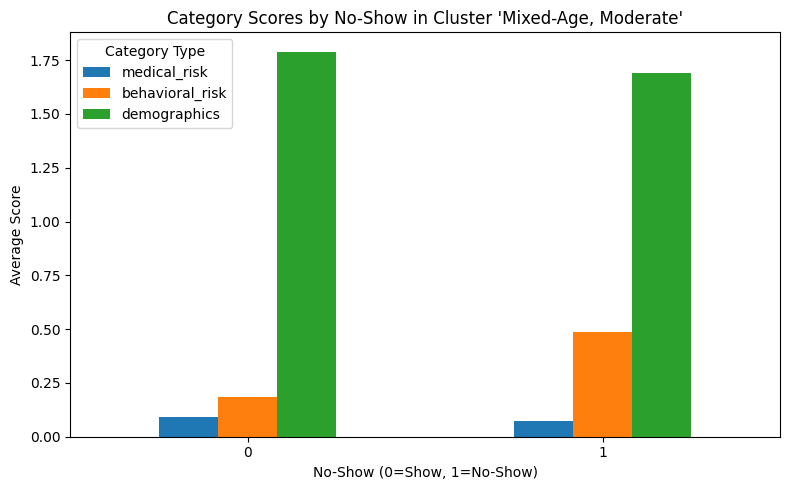

== Cluster: Older, High-Need ==
         medical_risk  behavioral_risk  demographics
no_show                                             
0            0.156501         0.242962      0.972287
1            0.168566         0.527355      0.922961


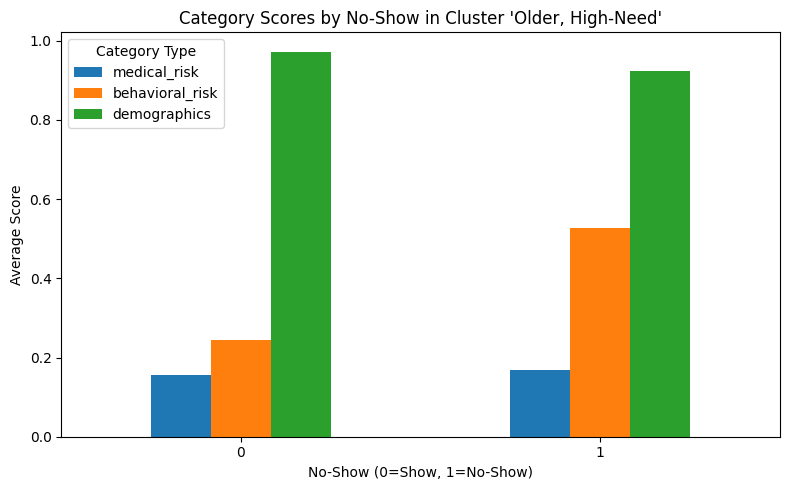

In [404]:
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=115)
clusters = kmeans.fit_predict(X)

# DataFrame and define categories
df_clusters = pd.DataFrame(X, columns=features)
df_clusters['cluster'] = clusters
df_clusters['no_show'] = y

medical_cols = ['hypertension', 'diabetes', 'alcoholism', 'handcap']
behavioral_cols = ['sms_received', 'days_between', 'past_missed']
demographic_cols = ['age', 'day_of_week']

# Calculate category scores and summary to define clusters
df_clusters['medical_risk'] = df_clusters[medical_cols].mean(axis=1)
df_clusters['behavioral_risk'] = df_clusters[behavioral_cols].mean(axis=1)
df_clusters['demographics'] = df_clusters[demographic_cols].mean(axis=1)

summary = df_clusters.groupby('cluster')[['medical_risk', 'behavioral_risk', 'demographics', 'no_show']].mean()

cluster_labels = { #based on interpretation of cluster summary
    0: 'Young, Low-Need',
    1: 'Mixed-Age, Moderate',
    2: 'Older, High-Need'
}

df_clusters['cluster_label'] = df_clusters['cluster'].map(cluster_labels)

# Compare calculated scores to no-show and plot
for cluster_id, cluster_name in cluster_labels.items():
    subset = df_clusters[df_clusters['cluster'] == cluster_id]

    print(f"== Cluster: {cluster_name} ==")

    summary = subset.groupby('no_show')[['medical_risk', 'behavioral_risk', 'demographics']].mean()
    print(summary)

    # Plot
    summary.plot(kind='bar', figsize=(8,5), title=f"Category Scores by No-Show in Cluster '{cluster_name}'")
    plt.xlabel('No-Show (0=Show, 1=No-Show)')
    plt.ylabel('Average Score')
    plt.xticks(rotation=0)
    plt.legend(title='Category Type')
    plt.tight_layout()
    plt.show()

Detecting anomalies with IsolationForest

cluster_label        anomaly_label
Mixed-Age, Moderate  Anomaly           1453
                     Normal           21675
Older, High-Need     Anomaly           1883
                     Normal           20967
Young, Low-Need      Anomaly            156
                     Normal           23694
dtype: int64


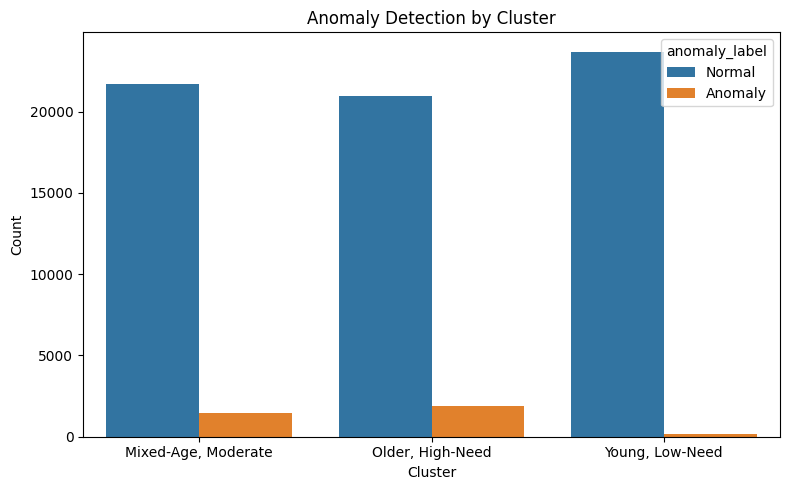

No-show rates by anomaly status:
anomaly_label
Anomaly    0.327892
Normal     0.283240
Name: no_show, dtype: float64


In [405]:
df_clusters['anomaly'] = IsolationForest(contamination=0.05, random_state=115).fit_predict(X)
df_clusters['anomaly_label'] = df_clusters['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print(df_clusters.groupby(['cluster_label', 'anomaly_label']).size())

plt.figure(figsize=(8,5))
sns.countplot(data=df_clusters, x='cluster_label', hue='anomaly_label')
plt.title('Anomaly Detection by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("No-show rates by anomaly status:")
print(df_clusters.groupby('anomaly_label')['no_show'].mean())

Permutation importance for KNN

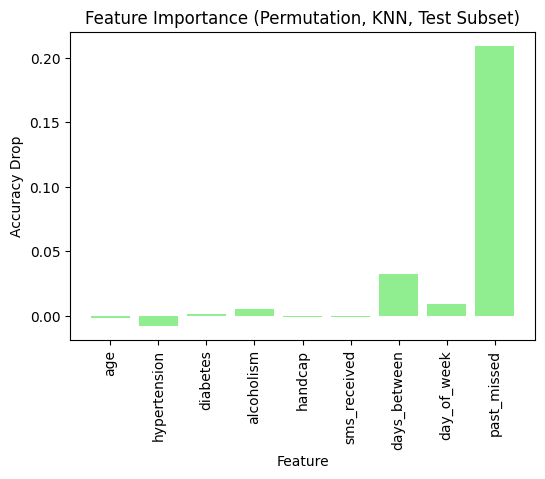

In [406]:
perm_importance_knn = []
subset_idx = np.random.choice(X_test.shape[0], size=X_test.shape[0]//10, replace=False)
X_test_subset = X_test[subset_idx]
y_test_subset = y_test[subset_idx]
subset_accuracy = np.mean(knn.predict(X_test_subset) == y_test_subset)
for i in range(X_test_subset.shape[1]):
    X_permuted = X_test_subset.copy()
    np.random.shuffle(X_permuted[:, i])
    perm_pred = knn.predict(X_permuted)
    perm_accuracy = np.mean(perm_pred == y_test_subset)
    perm_importance_knn.append(subset_accuracy - perm_accuracy)

plt.bar(features, perm_importance_knn, color='lightgreen')
plt.title('Feature Importance (Permutation, KNN, Test Subset)')
plt.xlabel('Feature')
plt.ylabel('Accuracy Drop')
plt.xticks(rotation=90)
plt.show()

Permutation importance for Random Forest

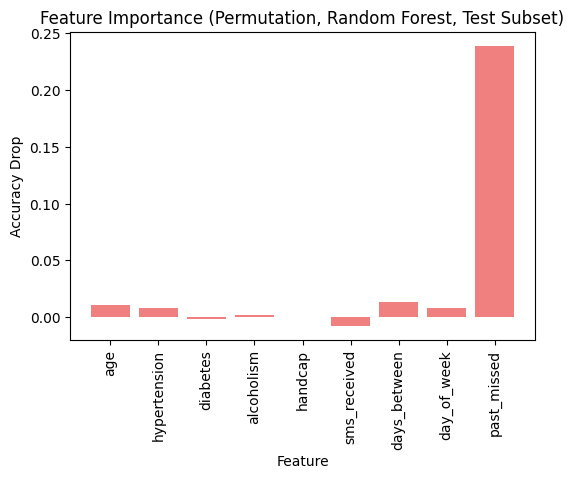

In [407]:
perm_importance_rf = permutation_importance(rf, X_test_subset, y_test_subset, n_repeats=10, random_state=115, n_jobs=-1)
plt.bar(features, perm_importance_rf.importances_mean, color='lightcoral')
plt.title('Feature Importance (Permutation, Random Forest, Test Subset)')
plt.xlabel('Feature')
plt.ylabel('Accuracy Drop')
plt.xticks(rotation=90)
plt.show()

**Results**: The machine learning evaluated models to predict medical appointment no-shows using supervised and unsupervised methods. A majority-class and baseline, predicting all patients show up, yields high accuracy but fails to identify no-shows. A median-based baseline, randomly predicting at the training no-show rate, shows no improvement. The K-Nearest Neighbors (KNN) model moderately enhances performance but struggles with the imbalanced dataset. Random Forest, an ensemble method, outperforms others, better balancing correct no-show predictions and capturing high-risk patients.

Key features like past missed appointments and SMS reminders strongly influence predictions, as shown by permutation importance. K-means clustering identifies distinct patient risk groups, with one showing higher no-show rates. Isolation Forest detects outliers with elevated no-show tendencies, suggesting anomalies are high-risk. These findings support targeted interventions to reduce no-shows, with Random Forest offering the most robust solution for clinic efficiency.

The answer for what causes missed appointments begs the question, but the findings show that there is little correlation between behavioral or demographic features and missed appointments in Brazil.